# Exam - Clarissa Eisenbach & Moritz Toppmöller

## Installation

In [1]:
# Using Python 3.14
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## The dataset

### The Myocardial infarction complications Database 
The database can be found at https://figshare.le.ac.uk/articles/dataset/Myocardial_infarction_complications_Database/12045261 with labeled columns
in the Machine Learning Repository the dataset does not have labeled colums https://archive.ics.uci.edu/dataset/579/myocardial+infarction+complications 


The dataset includes data on patients collected in the hospital after Myocardial Infarction (MI) on admission day and day three, and complications. 
Predicting complications after MI allows the clinician to provide preventive measures to the patient in time. 

### Dataset: 

#### column 1: index

#### colums 2-112: input data 
    2-3: demographic data
    4-34 preexisting conditions / symptoms /findings
    35-75 : findings on admission (BP, clinical, mostly ECG findings)
    76-82 : fibrinolytic therapy
    83-91 : findings (Labs)
    92: time to treatment
    93-95: relapse of pain
    96-112 : therapy / drugs by Emergency medical team / in ICU on day 1, 2, 3

#### columns 113-124: outputs = possible complications and patient outcomes
    112-117: arrythmias
    118: pulmonary edema
    119: myogardial rupture
    120: dressler syndrome
    121: Chronic heart failure
    122: Relapse of MI
    123: Post-infarction angina
    124: lethal outcome (cause)


There are four possible time moments for complication prediction: on base of the information known at
1.	the time of admission to hospital: all input columns (2-112) except 93, 94, 95, 100, 101, 102, 103, 104, 105 can be used for prediction;
2.	the end of the first day (24 hours after admission to the hospital): all input columns (2-112) except 94, 95, 101, 102, 104, 105 can be used for prediction;
3.	the end of the second day (48 hours after admission to the hospital) all input columns (2-112) except 95, 102, 105 can be used for prediction;
4.	the end of the third day (72 hours after admission to the hospital) all input columns (2-112) can be used for prediction.


### Brainstorming on Data Analysis for this Dataset:

1. Data preprocessing:
There are missing values in the dataset according to the info online - how to deal with those?
Features are binary (e.g. obesity 0- no, 1 - yes), ordinal (e.g. 9. Presence of hypertention 0-no, 1-Stage1, 2-Stage2, 3-Stage 3), or numerical (Blood pressure 35-38, Labs 84, 86-91)

2. Data Analysis:
Decision Tree could be a good algorithm for Risk prediction since it's understandable, which is important in a clinical context.

3. Performance Evaluation: compare two different models, maybe an XAI Model vs a black box Neural Network? to see if losing the explainability is worht it because of a gain in prediction performance?

In [2]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# import MIcomplications.csv into a pandas dataframe
mi_complications = pd.read_csv("MIcomplications.csv", index_col=0)
mi_complications.head()

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,DLIT_AG,...,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,ZSN,REC_IM,P_IM_STEN,LET_IS
ID,,,,,,,,,,,,,,,,,,,,,
1,77.0,1,2.0,1.0,1.0,2.0,NaN,3.0,0.0,7.0,...,0,0,0,0,0,0,0,0,0,0
2,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,52.0,1,0.0,0.0,0.0,2.0,NaN,2.0,0.0,2.0,...,0,0,0,0,0,0,0,0,0,0
4,68.0,0,0.0,0.0,0.0,2.0,NaN,2.0,0.0,3.0,...,0,0,0,0,0,0,1,0,0,0
5,60.0,1,0.0,0.0,0.0,2.0,NaN,3.0,0.0,7.0,...,0,0,0,0,0,0,0,0,0,0


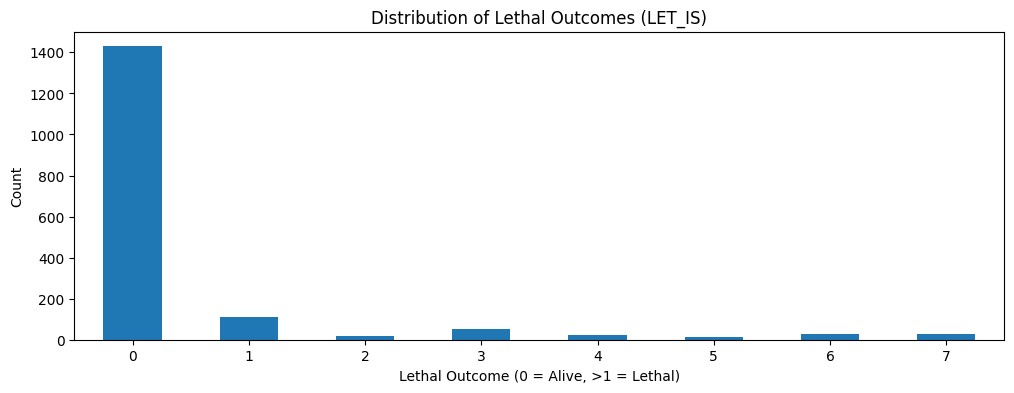

In [3]:
# show the distribution of the variable "LET_IS" in a bar plot
# note that 0 is called "alive" not "unknown" in the descriptive statistics document
plt.figure(figsize=(12, 4))
mi_complications["LET_IS"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Lethal Outcomes (LET_IS)")
plt.xlabel("Lethal Outcome (0 = Alive, >1 = Lethal)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [4]:
# find out how many missing values are in the dataset
missing_values = mi_complications.isnull().sum()
print("Number of missing values: ", missing_values.sum(),
    "out of", mi_complications.size,
    "(", round(missing_values.sum() / mi_complications.size * 100, 2), "%)"
)
print("Number of corrupted rows: ", mi_complications[mi_complications.isnull().any(axis=1)].shape[0],
    "out of", mi_complications.shape[0],
    "(", round(mi_complications[mi_complications.isnull().any(axis=1)].shape[0] / mi_complications.shape[0] * 100, 2), "%)"
)

# show columns without missing values
columns_without_missing_values = missing_values[missing_values == 0].index.tolist()
print("Columns without missing values: ", columns_without_missing_values)

# show columns sorted by the number of missing values and their percentage of missing values
missing_values_sorted = missing_values[missing_values != 0].sort_values(ascending=False)
missing_values_percentage = (missing_values_sorted / mi_complications.size * 100).round(2)
missing_values_df = pd.DataFrame({"Missing Values": missing_values_sorted, "Percentage": missing_values_percentage})
print(missing_values_df)

# show rows with missing values sorted by the number of missing values
rows_with_missing_values = mi_complications[mi_complications.isnull().any(axis=1)]
rows_with_missing_values["Missing Count"] = rows_with_missing_values.isnull().sum(axis=1)
rows_with_missing_values_sorted = rows_with_missing_values.sort_values(by="Missing Count", ascending=False)
print(rows_with_missing_values_sorted[["Missing Count"]])


Number of missing values:  15974 out of 209100 ( 7.64 %)
Number of corrupted rows:  1700 out of 1700 ( 100.0 %)
Columns without missing values:  ['SEX', 'FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC', 'RAZRIV', 'DRESSLER', 'ZSN', 'REC_IM', 'P_IM_STEN', 'LET_IS']
            Missing Values  Percentage
KFK_BLOOD             1696        0.81
IBS_NASL              1628        0.78
D_AD_KBRIG            1076        0.51
S_AD_KBRIG            1076        0.51
NOT_NA_KB              686        0.33
...                    ...         ...
zab_leg_06               7        0.00
zab_leg_04               7        0.00
NA_R_1_n                 5        0.00
INF_ANAM                 4        0.00
IM_PG_P                  1        0.00

[110 rows x 2 columns]
      Missing Count
ID                 
1595             60
1589             54
726              48
1510             46
1576             43
...             ...
457               1
267               1
395           

/var/folders/j7/7ljlhfy52_56rp4fy1q_lckc0000gp/T/ipykernel_7317/4116056644.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rows_with_missing_values["Missing Count"] = rows_with_missing_values.isnull().sum(axis=1)


## Data Preprocessing

In [5]:
# TODO

## Model 1: Decision Tree

### Decision Tree to predict Lethal Outcome

A Decision Tree is understandablen (XAI), making it a good algorithm to base clinical decisions on.
Decision Trees don't need a data preprocessing step of feature scaling because it makes decisions based on thresholds.

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       288
           1       0.46      0.50      0.48        52

    accuracy                           0.83       340
   macro avg       0.68      0.70      0.69       340
weighted avg       0.84      0.83      0.84       340

Confusion Matrix:


/var/folders/j7/7ljlhfy52_56rp4fy1q_lckc0000gp/T/ipykernel_7317/1752836924.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mi_complications["lethal_outcome"] = mi_complications["LET_IS"].apply(lambda x: 0 if x == 0 else 1)


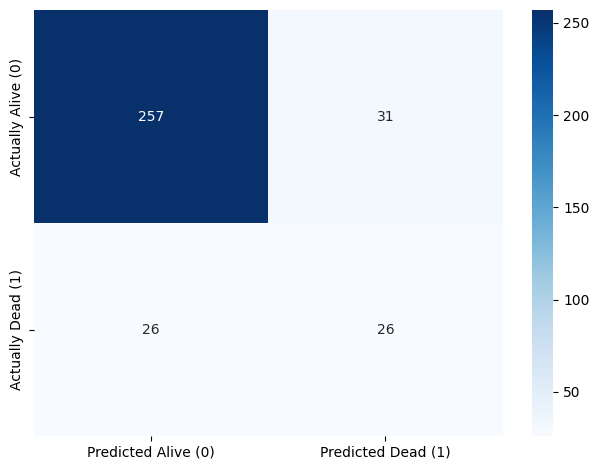

Specificity: 0.892
Sensitivity: 0.500
Feature Importances:
          feature  importance
26      endocr_02    0.110939
98       NA_R_1_n    0.076667
77    fibr_ter_05    0.073973
100      NA_R_3_n    0.050870
83       GIPER_NA    0.044720
87      KFK_BLOOD    0.042487
70   n_p_ecg_p_09    0.041455
89            ROE    0.039914
99       NA_R_2_n    0.031685
104       LID_S_n    0.031321


In [6]:
# predict a lethal outcome using a decision tree (doesn't need feature scaling for labs or BP) 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import seaborn as sns
import matplotlib.pyplot as plt

# separate the target variable from the features: columns 2-112 are features, column 124 LET_IS is the target variable
# LET_IS is "negative" for alive, value 0, and "positive" for deceased, values 1-7
X = mi_complications.iloc[:, 0:110]
mi_complications["lethal_outcome"] = mi_complications["LET_IS"].apply(lambda x: 0 if x == 0 else 1)
y = mi_complications["lethal_outcome"]
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# for handling missing values, identify column types binary or numeric ordinal 
binary_features = [col for col in X.columns if X[col].dropna().isin([0, 1]).all()]
numeric_features = [col for col in X.select_dtypes(include=["int64", "float64"]).columns 
                    if col not in binary_features]

# for decision trees, use most frequent for binary features, and median imputation for ordinal and categorical features
# decision trees make threshold splits - if we use logistic regression later we need to revisit!! 

# transformers:
binary_transformer = SimpleImputer(strategy="most_frequent")
numeric_transformer = SimpleImputer(strategy="median")

# preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("bin", binary_transformer, binary_features),
        ("num", numeric_transformer, numeric_features),
    ]
)
# create a pipeline that combines the preprocessor with a decision tree classifier
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])
# fit the pipeline to the training data
pipeline.fit(X_train, y_train)
# make predictions on the test set
y_pred = pipeline.predict(X_test)
# evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
# create a confusion matrix and visualize it with seaborn
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Alive (0)", "Predicted Dead (1)"],
            yticklabels=["Actually Alive (0)", "Actually Dead (1)"])
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
print(f"Specificity: {specificity:.3f}")  # ability to correctly identify alive patients
print(f"Sensitivity: {sensitivity:.3f}") # ability to correctly identify dying patients


# describe which features are most important for predicting lethal outcomes in the decision tree model
feature_importances = pipeline.named_steps["classifier"].feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": feature_importances})
feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)
print("Feature Importances:")
print(feature_importance_df.head(10))   

For our question it is important to correctly identify patients at risk of dying to intervene in time.
The Model has a Sensitivity of only 50%, meaning it correctly predicted death in only half of patients who actually deceased. This performance is not sufficient, as half of the high-risk patients were not flagged. 


Which features were most important for the prediction?
Obesity, Opioid use (NA_R), fibrinolytic therapy by Celiasum 500k, Blood sodium, CPK and ESR, and some ECG changes.

Note: Interventions such as Fibrinolytic Therapy or use of NSAIDs could be associated with death because sicker patients recieve more drugs! It might be better to exclude Theurapeutic interventions from the predictive model and use only findings. 

In [7]:
# print the first 5 rows of column 112:
print(mi_complications.iloc[:, 93].head())

ID
1    1.0
2    0.0
3    0.0
4    1.0
5    0.0
Name: R_AB_3_n, dtype: float64


Classification Report for Findings Only Tree Model:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       288
           1       0.33      0.35      0.34        52

    accuracy                           0.79       340
   macro avg       0.61      0.61      0.61       340
weighted avg       0.80      0.79      0.80       340

Confusion Matrix:


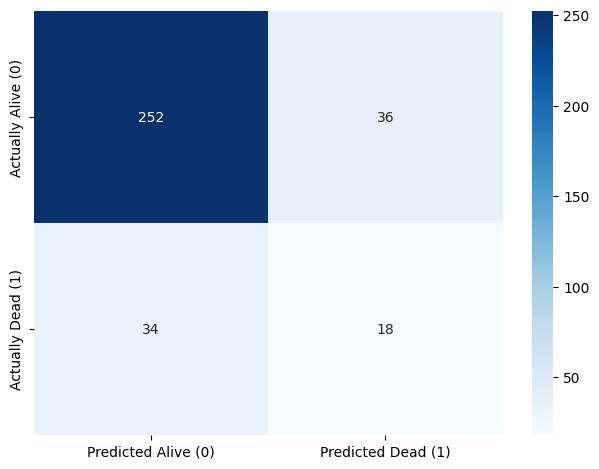

Specificity: 0.875
Sensitivity: 0.346
Feature Importances for Findings Only Tree Model:
         feature  importance
80       L_BLOOD    0.116369
26     endocr_02    0.110939
59  n_r_ecg_p_06    0.091631
75      GIPER_NA    0.041264
72  n_p_ecg_p_11    0.040782
61  n_r_ecg_p_09    0.039575
78     AST_BLOOD    0.038982
81           ROE    0.038173
32    zab_leg_06    0.036381
82      TIME_B_S    0.035713


In [8]:
# predict a lethal outcome using a decision tree, using findings only (excluding therapeutic interventions)
# excluded columns 76-82 (fibrinolytic therapies) and 96-112 (drugs/interventions)


# features 2-75 are findings (index 0:73), excluding intervention features 76-82 and 96-112
findings_columns = list(mi_complications.columns[0:73]) + list(mi_complications.columns[81:93])
X = mi_complications[findings_columns]

mi_complications["lethal_outcome"] = mi_complications["LET_IS"].apply(lambda x: 0 if x == 0 else 1)
y = mi_complications["lethal_outcome"]

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# for handling missing values, identify column types binary or numeric ordinal 
binary_features = [col for col in X.columns if X[col].dropna().isin([0, 1]).all()]
numeric_features = [col for col in X.select_dtypes(include=["int64", "float64"]).columns 
                    if col not in binary_features]

# for decision trees, use most frequent for binary features, and median imputation for ordinal and numeric features
# decision trees make threshold splits - if we use logistic regression later we need to revisit!! 
binary_transformer = SimpleImputer(strategy="most_frequent")
numeric_transformer = SimpleImputer(strategy="median")

# preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("bin", binary_transformer, binary_features),
        ("num", numeric_transformer, numeric_features),
    ]
)

# create a pipeline that combines the preprocessor with a decision tree classifier
pipeline_findings = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# fit the pipeline to the training data
pipeline_findings.fit(X_train, y_train)

# make predictions on the test set
y_pred = pipeline_findings.predict(X_test)

# evaluate the model
print("Classification Report for Findings Only Tree Model:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Alive (0)", "Predicted Dead (1)"],
            yticklabels=["Actually Alive (0)", "Actually Dead (1)"])
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
print(f"Specificity: {specificity:.3f}")  # ability to correctly identify alive patients
print(f"Sensitivity: {sensitivity:.3f}") # ability to correctly identify dying patients


# describe which features are most important for predicting lethal outcomes
feature_importances = pipeline_findings.named_steps["classifier"].feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": feature_importances})
feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)
print("Feature Importances for Findings Only Tree Model:")
print(feature_importance_df.head(10))

The decision tree model using only the findings as input shows performs worse (makes sense). A sensitivity of 34.6% is quite underwhelming, since only 18 of 52 deceased patients will be flagged as "high risk".


The predictive features, obesity (endocr_02) is now second important, still 11%, White Blood Cell Count (an inflammation marker) is most important with 11%, as is ESR (ROE, also inflammation marker), AST (a liver function marker), and ECG changes. 
These are quite helpful markers identifyable right on admission of the patient to allow monitoring them more closely. 


It could be interesting how well the model performs for different causes of death, or how it performs if we drop the cases with missing values instead of imputing them. 

In [9]:
# compare the sensitivity of the model for different causes of death (LET_IS values 1-7)
#  add predictions to the test set
X_test_copy = X_test.copy()
X_test_copy["y_test"] = y_test.values
X_test_copy["y_pred"] = y_pred
X_test_copy["LET_IS"] = mi_complications.loc[X_test.index, "LET_IS"].values

# filter for actually dead patients (y_test == 1)
dead_patients = X_test_copy[X_test_copy["y_test"] == 1]

# correctly identified dead patients (TP)
correctly_identified = dead_patients[dead_patients["y_pred"] == 1]
print("Causes of death - correctly identified (TP):")
print(correctly_identified["LET_IS"].value_counts())

# missed dead patients (FN)
missed = dead_patients[dead_patients["y_pred"] == 0]
print("\nCauses of death - missed (FN):")
print(missed["LET_IS"].value_counts())

# sensitivity for each cause of death
cause_map = {
    1: "Cardiogenic shock",
    2: "Pulmonary edema",
    3: "Myocardial rupture",
    4: "Congestive heart failure",
    5: "Thromboembolism",
    6: "Asystole",
    7: "Ventricular fibrillation"
}

print("Sensitivity by cause of death:")
for cause, name in cause_map.items():
    tp = len(correctly_identified[correctly_identified["LET_IS"] == cause])
    fn = len(missed[missed["LET_IS"] == cause])
    total = tp + fn
    if total > 0:
        sensitivity = tp / total
        print(f"{name}: {tp}/{total} = {sensitivity:.2f}")
    else:
        print(f"{name}: no cases in test set")

Causes of death - correctly identified (TP):
LET_IS
1    12
3     3
2     1
5     1
7     1
Name: count, dtype: int64

Causes of death - missed (FN):
LET_IS
1    11
4     8
3     8
6     3
7     3
5     1
Name: count, dtype: int64
Sensitivity by cause of death:
Cardiogenic shock: 12/23 = 0.52
Pulmonary edema: 1/1 = 1.00
Myocardial rupture: 3/11 = 0.27
Congestive heart failure: 0/8 = 0.00
Thromboembolism: 1/2 = 0.50
Asystole: 0/3 = 0.00
Ventricular fibrillation: 1/4 = 0.25


The Prediction was best for the cause of death of Cardiogenic shock, which had the most cases - maybe there wasn't enough data in the dataset to predict the risk of death from other causes better..

Classification Report for Chronic Heart Failure Tree Model:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       260
           1       0.49      0.42      0.46        80

    accuracy                           0.76       340
   macro avg       0.66      0.65      0.65       340
weighted avg       0.75      0.76      0.76       340

Confusion Matrix:


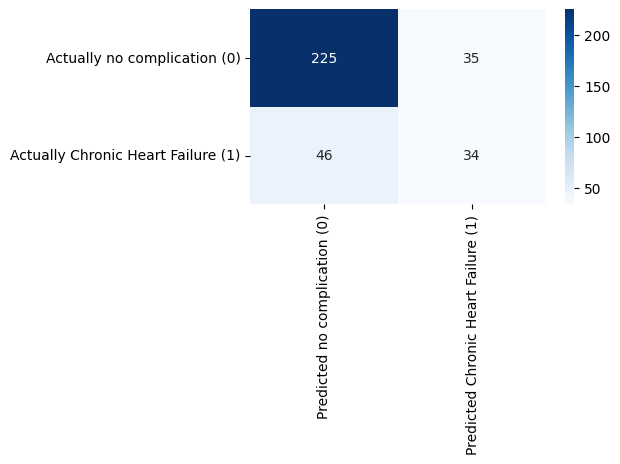

Specificity: 0.865
Sensitivity: 0.425
Feature Importances for predicting Chronic Heart Failure:
         feature  importance
66  n_p_ecg_p_05    0.149764
59  n_r_ecg_p_06    0.084877
81           ROE    0.071979
78     AST_BLOOD    0.065139
80       L_BLOOD    0.061243
77     ALT_BLOOD    0.057965
69  n_p_ecg_p_08    0.049853
75      GIPER_NA    0.034152
76      NA_BLOOD    0.031686
72  n_p_ecg_p_11    0.027704


In [10]:
# EXKURS from research question: 
# predict the complication Chronic Heart falure, which is a fraction of 23.18% of all cases, using a decision tree classifier with the same features and pipeline as above, and evaluate the model performance.

findings_columns = list(mi_complications.columns[0:73]) + list(mi_complications.columns[81:93])
X = mi_complications[findings_columns]

y = mi_complications["ZSN"]  # ZSN is the column for chronic heart failure

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# for handling missing values, identify column types binary or numeric ordinal 
binary_features = [col for col in X.columns if X[col].dropna().isin([0, 1]).all()]
numeric_features = [col for col in X.select_dtypes(include=["int64", "float64"]).columns 
                    if col not in binary_features]

binary_transformer = SimpleImputer(strategy="most_frequent")
numeric_transformer = SimpleImputer(strategy="median")

# preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("bin", binary_transformer, binary_features),
        ("num", numeric_transformer, numeric_features),
    ]
)

# create a pipeline that combines the preprocessor with a decision tree classifier
pipeline_findings = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# fit the pipeline to the training data
pipeline_findings.fit(X_train, y_train)

# make predictions on the test set
y_pred = pipeline_findings.predict(X_test)

# evaluate the model
print("Classification Report for Chronic Heart Failure Tree Model:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted no complication (0)", "Predicted Chronic Heart Failure (1)"],
            yticklabels=["Actually no complication (0)", "Actually Chronic Heart Failure (1)"])
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
print(f"Specificity: {specificity:.3f}") 
print(f"Sensitivity: {sensitivity:.3f}") 


# describe which features are most important for predicting lethal outcomes
feature_importances = pipeline_findings.named_steps["classifier"].feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": feature_importances})
feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)
print("Feature Importances for predicting Chronic Heart Failure:")
print(feature_importance_df.head(10))

## Model 2: Neural Network

### Neural Network to predict Lethal Outcome

In [11]:
# TODO

A Decision Tree Model using only findings as input features performs with a sensitivity of 0.42%, so this model is better than the one predicting death - supporting the hypothesis that the model gets better with more datapoints for a certain outcome. (outcome Chronic heart failure: 32%, vs lethal outcome 15.94%)